# Seasonal Agriculture Performance Analysis
## Optimized Data Analytics Project

**Domain:** Agriculture  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

---

## 1. Project Overview
This data analytics project focuses on a comprehensive, farm-level investigation of agricultural production cycles to evaluate how varying seasonal, environmental, and operational factors intersect to dictate overall crop yields and subsequent business profitability. Operating on a robust dataset of 4,000 distinct agricultural records across 28 multi-disciplinary variables, this study moves past traditional localized assumptions to extract evidence-based trends regarding resource usage, financial returns, and climate resilience.The core motivation behind this analysis is the standard agricultural optimization dilemma: How can modern farms maximize food production volumes while ensuring commercial financial survival and sustainable natural resource management? By inspecting these data patterns, this project builds structured data pipelines to clear away noise and support strategic decision-making. Structural Scope of the Analysis

### Problem Statement
Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability, and economic conditions. This project analyzes a farm‑level agricultural dataset to investigate seasonal differences in performance, identify patterns, trends, relationships, and variations across seasons.

### Objectives
- Understand the dataset structure and quality
- Clean and prepare data for analysis
- Explore seasonal patterns
- Perform descriptive and statistical analysis
- Investigate relationships among variables
- Compare agricultural performance across seasons and groups
- Use appropriate visualizations
- Identify significant findings
- Develop evidence‑based insights and recommendations

### Dataset
The dataset contains farm‑level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit, and resource usage.



In [1]:
# -*- coding: utf-8 -*-
"""Seasonal Agriculture Performance Analysis - Optimized Version

This notebook provides a comprehensive analysis of agricultural performance 
across seasons using Python data analysis tools.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from typing import Optional, List, Tuple, Dict, Any
from pathlib import Path

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Configure plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid", palette="viridis")

# Configure pandas display
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print("=" * 70)
print("SEASONAL AGRICULTURE PERFORMANCE ANALYSIS")
print("=" * 70)

SEASONAL AGRICULTURE PERFORMANCE ANALYSIS


In [2]:
from pathlib import Path

class DataLoader:
    """Handle data loading with multiple fallback options."""
    
    def __init__(self, filename: str = "seasonal_agriculture_performance_dataset.csv"):
        self.filename = filename
        self.df = None
        
    def load(self) -> pd.DataFrame:
        """Load data from various possible locations."""
        # Use Path objects for cross‑platform compatibility
        search_paths = [
            Path.cwd() / self.filename,
            Path.cwd().parent / self.filename,
            Path("/content") / self.filename,                     # for Colab
            Path("E:/aicte_internship") / self.filename,          # your specific path (forward slashes)
            Path(r"E:\aicte_internship") / self.filename,         # raw string with backslashes
        ]
        
        for path in search_paths:
            if path.exists():
                print(f"✅ Data loaded from: {path}")
                self.df = pd.read_csv(path)   # <-- use the path variable, not a hard‑coded string
                return self.df
        
        raise FileNotFoundError(f"Dataset '{self.filename}' not found in any search path.")
    
    def get_data(self) -> pd.DataFrame:
        if self.df is None:
            self.load()
        return self.df

# Load the data
loader = DataLoader()
df = loader.load()
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

✅ Data loaded from: e:\aicte_internship\seasonal_agriculture_performance_dataset.csv
Dataset shape: 4,000 rows × 28 columns


In [3]:
class DataCleaner:
    """Clean and prepare the agricultural dataset."""
    
    def __init__(self, df: pd.DataFrame):
        self.df = df.copy()
        
    def clean(self) -> pd.DataFrame:
        """Execute full cleaning pipeline."""
        self._standardize_columns()
        self._handle_missing_values()
        self._remove_duplicates()
        return self.df
    
    def _standardize_columns(self):
        """Standardize column names to lowercase with underscores."""
        self.df.columns = (self.df.columns
                          .str.strip()
                          .str.lower()
                          .str.replace(' ', '_'))
        print("✅ Column names standardized")
    
    def _handle_missing_values(self):
        """Handle missing values with appropriate strategies."""
        missing_before = self.df.isnull().sum().sum()
        
        # Use median for numerical columns with missing values
        numeric_cols = self.df.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            if self.df[col].isnull().sum() > 0:
                self.df[col] = self.df[col].fillna(self.df[col].median())
        
        missing_after = self.df.isnull().sum().sum()
        print(f"✅ Missing values: {missing_before} → {missing_after}")
    
    def _remove_duplicates(self):
        """Remove duplicate rows."""
        before = len(self.df)
        self.df = self.df.drop_duplicates().reset_index(drop=True)
        removed = before - len(self.df)
        print(f"✅ Duplicates removed: {removed} rows")
    
    def get_quality_report(self) -> pd.DataFrame:
        """Generate a data quality report."""
        report = pd.DataFrame({
            'Column': self.df.columns,
            'Data_Type': self.df.dtypes.values,
            'Non_Null': self.df.notnull().sum().values,
            'Null_Count': self.df.isnull().sum().values,
            'Unique_Values': self.df.nunique().values,
        })
        return report

# Clean the data
cleaner = DataCleaner(df)
df = cleaner.clean()
quality_report = cleaner.get_quality_report()
print("\n📊 Data Quality Report:")
print(quality_report.to_string(index=False))

✅ Column names standardized
✅ Missing values: 120 → 0
✅ Duplicates removed: 0 rows

📊 Data Quality Report:
                       Column Data_Type  Non_Null  Null_Count  Unique_Values
                      farm_id    object      4000           0           4000
                        state    object      4000           0              8
                     district    object      4000           0             10
                         crop    object      4000           0              8
                       season    object      4000           0              3
           farm_area_hectares   float64      4000           0           1370
                  rainfall_mm   float64      4000           0           3256
            avg_temperature_c   float64      4000           0            204
                 humidity_pct   float64      4000           0            573
           sunlight_hours_day   float64      4000           0             71
                      soil_ph   float64      4


📊 Summary Statistics:
                                 count       mean        std           min  \
farm_area_hectares            4,000.00       7.89       4.22          0.50   
rainfall_mm                   4,000.00     600.92     287.19         80.00   
avg_temperature_c             4,000.00      26.82       3.82         16.20   
humidity_pct                  4,000.00      63.21      11.96         25.00   
sunlight_hours_day            4,000.00       7.32       1.12          3.50   
soil_ph                       4,000.00       6.70       0.64          5.20   
soil_moisture_pct             4,000.00      26.51       6.68          8.00   
nitrogen_kg_ha                4,000.00     120.25      31.22         40.00   
phosphorus_kg_ha              4,000.00      57.78      17.02         15.00   
potassium_kg_ha               4,000.00     104.76      27.74         30.00   
fertilizer_kg_ha              4,000.00     186.04      60.26         40.00   
pesticide_litre_ha            4,000.00   

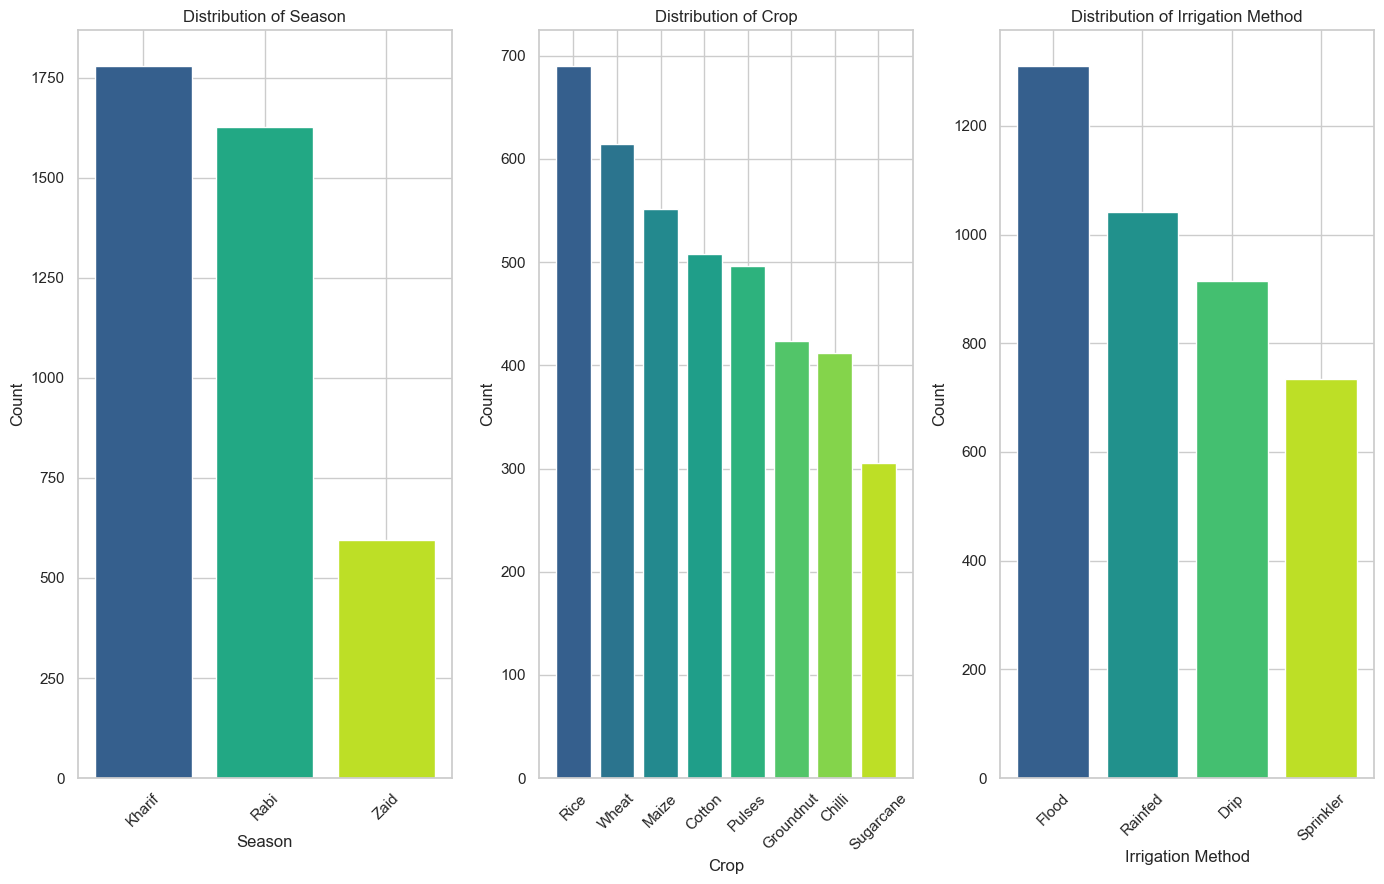

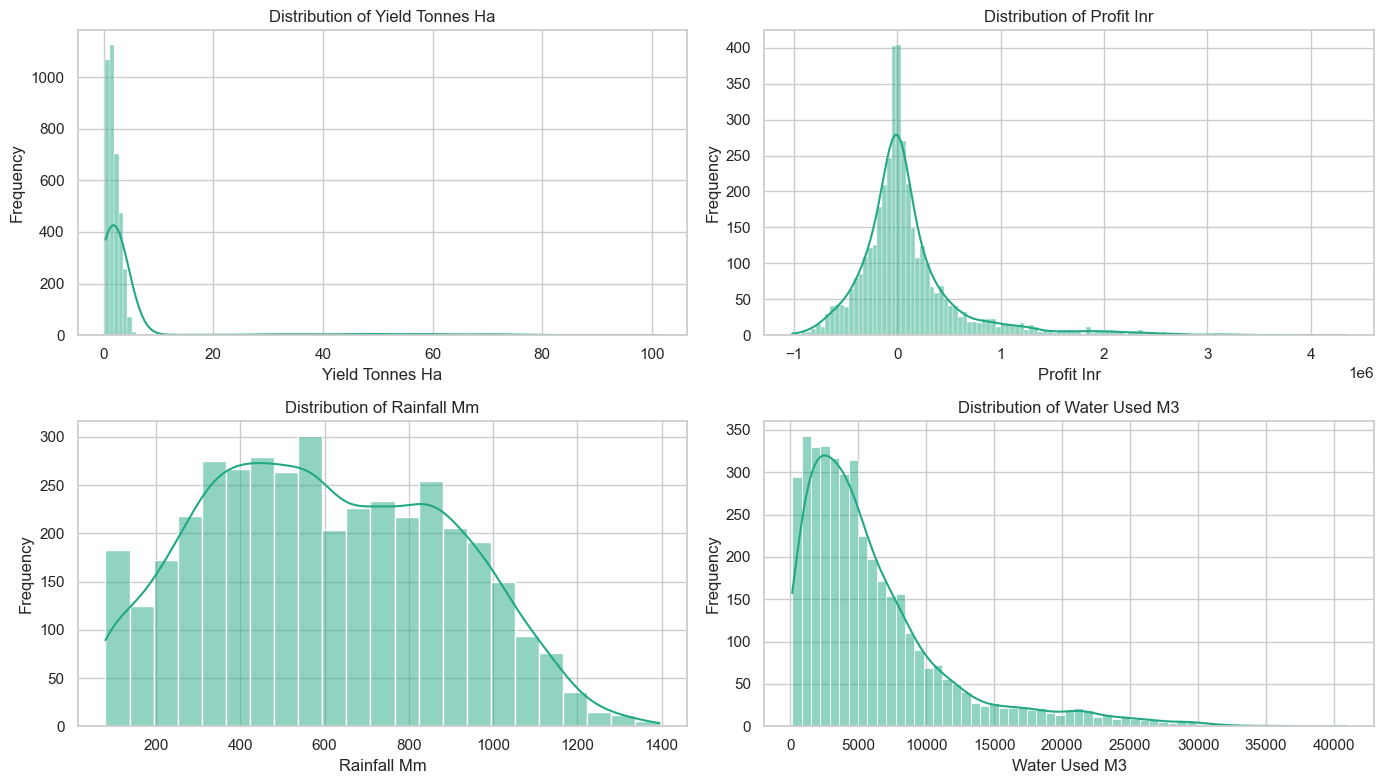

In [4]:
class EDAnalyzer:
    """Comprehensive Exploratory Data Analysis."""
    
    def __init__(self, df: pd.DataFrame):
        self.df = df
        self.numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        self.categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
        
    def summary_statistics(self) -> pd.DataFrame:
        """Generate comprehensive summary statistics."""
        stats = self.df[self.numeric_cols].describe().T
        stats['range'] = stats['max'] - stats['min']
        stats['iqr'] = stats['75%'] - stats['25%']
        stats['cv'] = stats['std'] / stats['mean']  # Coefficient of variation
        return stats
    
    def categorical_summary(self) -> pd.DataFrame:
        """Summarize categorical variables."""
        cat_stats = []
        for col in self.categorical_cols:
            counts = self.df[col].value_counts()
            cat_stats.append({
                'Column': col,
                'Unique_Values': len(counts),
                'Most_Common': counts.index[0],
                'Frequency': counts.iloc[0],
                'Frequency_%': (counts.iloc[0] / len(self.df)) * 100
            })
        return pd.DataFrame(cat_stats)
    
    def plot_categorical_distributions(self, cols: Optional[List[str]] = None, 
                                        figsize: Tuple[int, int] = (14, 6)):
        """Plot distribution of categorical variables."""
        if cols is None:
            cols = ['season', 'crop', 'irrigation_method']
        
        cols = [c for c in cols if c in self.df.columns]
        n = len(cols)
        
        fig, axes = plt.subplots(1, n, figsize=(figsize[0], figsize[1] * n/2))
        if n == 1:
            axes = [axes]
        
        for ax, col in zip(axes, cols):
            counts = self.df[col].value_counts()
            ax.bar(counts.index, counts.values, color=plt.cm.viridis(np.linspace(0.3, 0.9, len(counts))))
            ax.set_title(f'Distribution of {col.replace("_", " ").title()}')
            ax.set_xlabel(col.replace('_', ' ').title())
            ax.set_ylabel('Count')
            ax.tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
    
    def plot_numerical_distributions(self, cols: Optional[List[str]] = None,
                                      figsize: Tuple[int, int] = (14, 8)):
        """Plot distribution of numerical variables."""
        if cols is None:
            cols = ['yield_tonnes_ha', 'profit_inr', 'rainfall_mm', 'water_used_m3']
        
        cols = [c for c in cols if c in self.df.columns]
        n = len(cols)
        rows = (n + 1) // 2
        
        fig, axes = plt.subplots(rows, 2, figsize=figsize)
        axes = axes.flatten() if rows > 1 else [axes[0], axes[1]] if n > 1 else [axes]
        
        for i, col in enumerate(cols):
            ax = axes[i]
            sns.histplot(data=self.df, x=col, kde=True, ax=ax, color=plt.cm.viridis(0.6))
            ax.set_title(f'Distribution of {col.replace("_", " ").title()}')
            ax.set_xlabel(col.replace('_', ' ').title())
            ax.set_ylabel('Frequency')
        
        # Hide unused subplots
        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)
        
        plt.tight_layout()
        plt.show()

# Execute EDA
analyzer = EDAnalyzer(df)

print("\n📊 Summary Statistics:")
print(analyzer.summary_statistics().round(2))

print("\n📊 Categorical Summary:")
print(analyzer.categorical_summary())

# Visualizations
analyzer.plot_categorical_distributions()
analyzer.plot_numerical_distributions()


🌾 Seasonal Summary:
        yield_tonnes_ha_mean  yield_tonnes_ha_median  yield_tonnes_ha_std  \
season                                                                      
Kharif                  5.63                    1.94                14.39   
Rabi                    5.04                    1.67                12.75   
Zaid                    4.64                    1.46                11.27   

        production_tonnes_mean  production_tonnes_median  \
season                                                     
Kharif                   46.31                     13.24   
Rabi                     41.49                     11.08   
Zaid                     38.89                      9.97   

        production_tonnes_std  profit_inr_mean  profit_inr_median  \
season                                                              
Kharif                 135.70       178,914.65          38,808.00   
Rabi                   121.90        87,689.47          -3,187.00   
Zaid            

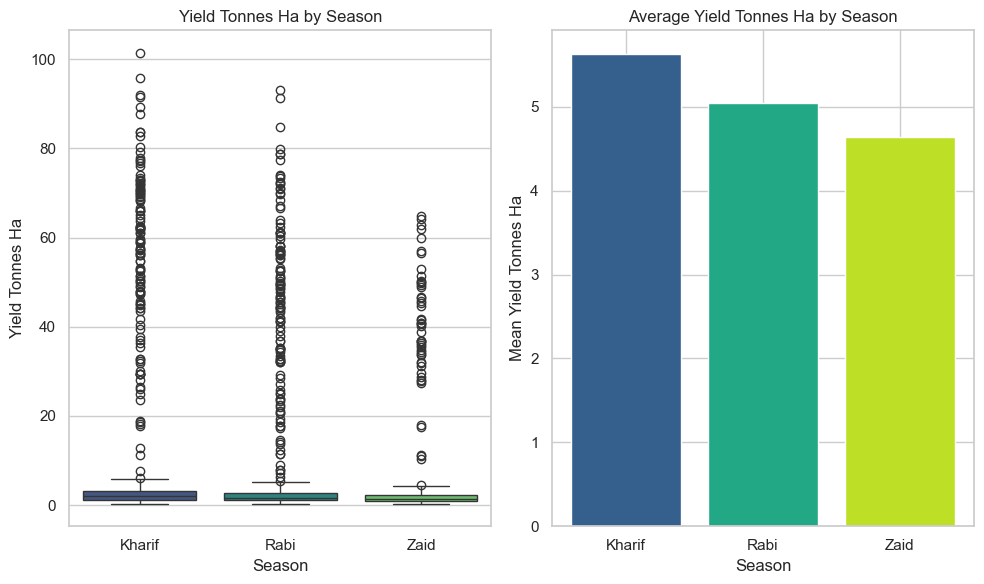


📊 Yield Tonnes Ha Statistics by Season:
          count  mean   std  min  25%  50%  75%    max
season                                                
Kharif 1,779.00  5.63 14.39 0.30 1.18 1.94 3.10 101.44
Rabi   1,627.00  5.04 12.75 0.30 1.02 1.67 2.74  93.13
Zaid     594.00  4.64 11.27 0.30 0.86 1.46 2.28  64.76


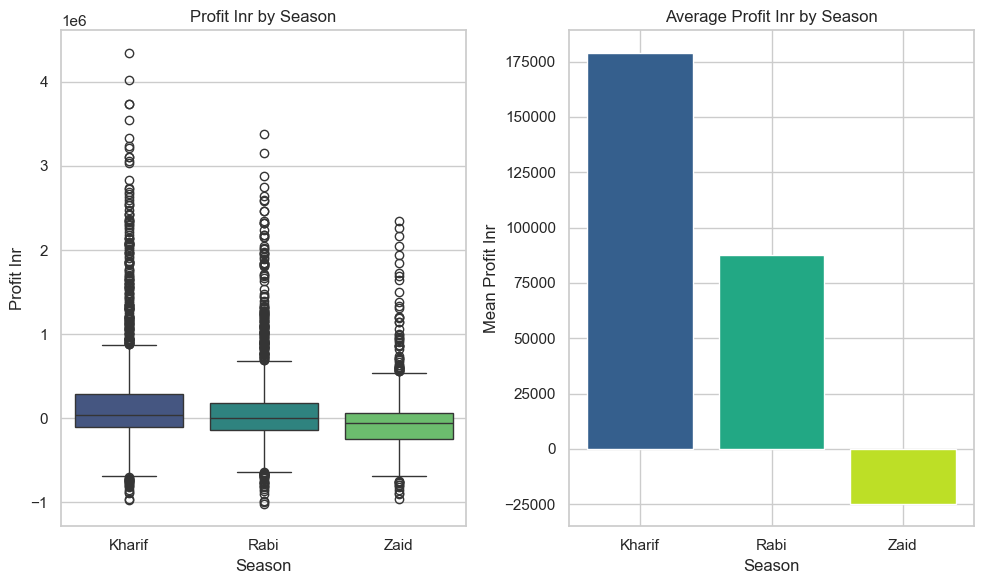


📊 Profit Inr Statistics by Season:
          count       mean        std           min         25%        50%  \
season                                                                       
Kharif 1,779.00 178,914.65 611,549.78   -976,860.00 -108,481.00  38,808.00   
Rabi   1,627.00  87,689.47 489,901.25 -1,019,223.00 -145,342.50  -3,187.00   
Zaid     594.00 -24,804.82 436,356.75   -965,197.00 -254,893.00 -62,144.00   

              75%          max  
season                          
Kharif 285,549.00 4,345,421.00  
Rabi   183,358.50 3,378,879.00  
Zaid    62,730.25 2,349,990.00  


In [5]:
class SeasonalAnalyzer:
    """Analyze agricultural performance by season."""
    
    def __init__(self, df: pd.DataFrame):
        self.df = df
        self.season_col = 'season'
        
    def summary_by_season(self, metrics: Optional[List[str]] = None) -> pd.DataFrame:
        """Calculate key metrics grouped by season."""
        if metrics is None:
            metrics = [
                'yield_tonnes_ha', 'production_tonnes', 
                'profit_inr', 'water_efficiency_t_per_1000m3',
                'rainfall_mm', 'fertilizer_kg_ha'
            ]
        
        metrics = [m for m in metrics if m in self.df.columns]
        
        summary = self.df.groupby(self.season_col)[metrics].agg(['mean', 'median', 'std'])
        
        # Flatten MultiIndex columns
        summary.columns = [f'{col[0]}_{col[1]}' for col in summary.columns]
        return summary.round(2)
    
    def plot_season_comparison(self, metric: str, figsize: Tuple[int, int] = (10, 6)):
        """Compare a metric across seasons."""
        if metric not in self.df.columns:
            print(f"❌ Column '{metric}' not found")
            return
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        
        # Boxplot
        sns.boxplot(data=self.df, x=self.season_col, y=metric, ax=ax1, 
                    palette='viridis')
        ax1.set_title(f'{metric.replace("_", " ").title()} by Season')
        ax1.set_xlabel('Season')
        ax1.set_ylabel(metric.replace('_', ' ').title())
        
        # Bar plot with means
        means = self.df.groupby(self.season_col)[metric].mean().sort_values(ascending=False)
        ax2.bar(means.index, means.values, color=plt.cm.viridis(np.linspace(0.3, 0.9, len(means))))
        ax2.set_title(f'Average {metric.replace("_", " ").title()} by Season')
        ax2.set_xlabel('Season')
        ax2.set_ylabel(f'Mean {metric.replace("_", " ").title()}')
        
        plt.tight_layout()
        plt.show()
        
        # Print statistics
        print(f"\n📊 {metric.replace('_', ' ').title()} Statistics by Season:")
        print(self.df.groupby(self.season_col)[metric].describe().round(2))

# Execute seasonal analysis
seasonal_analyzer = SeasonalAnalyzer(df)

print("\n🌾 Seasonal Summary:")
print(seasonal_analyzer.summary_by_season())

# Visualize key metrics
seasonal_analyzer.plot_season_comparison('yield_tonnes_ha')
seasonal_analyzer.plot_season_comparison('profit_inr')

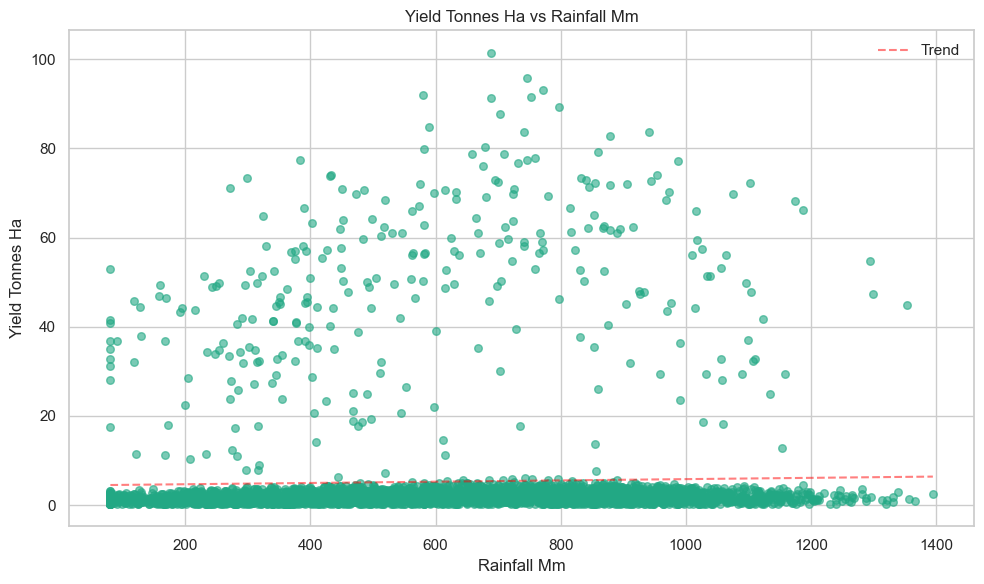

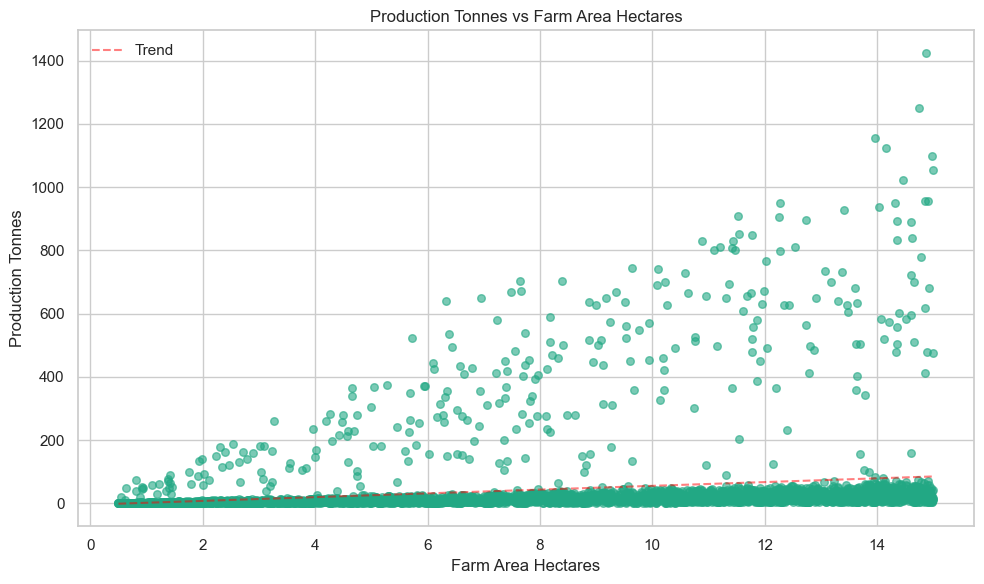

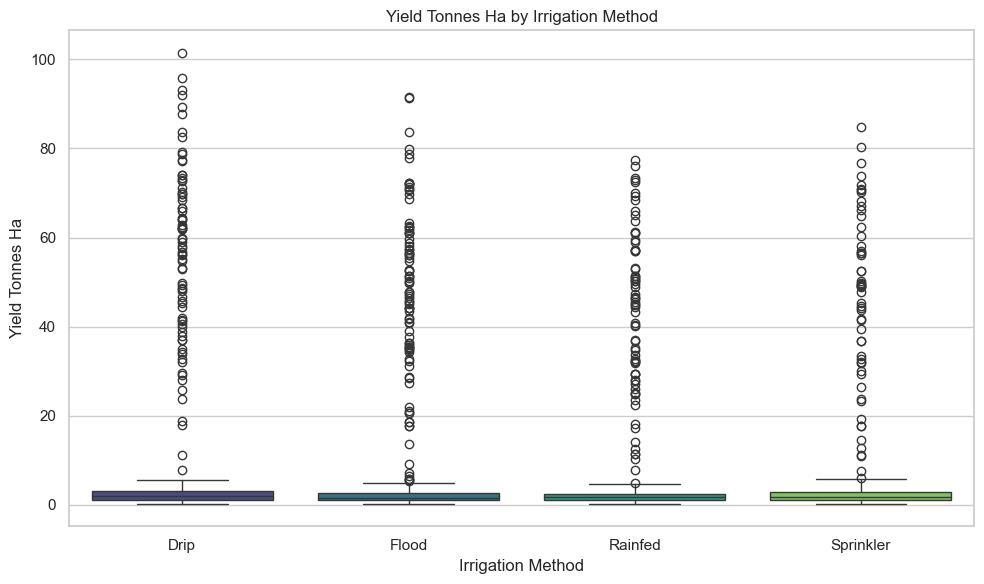

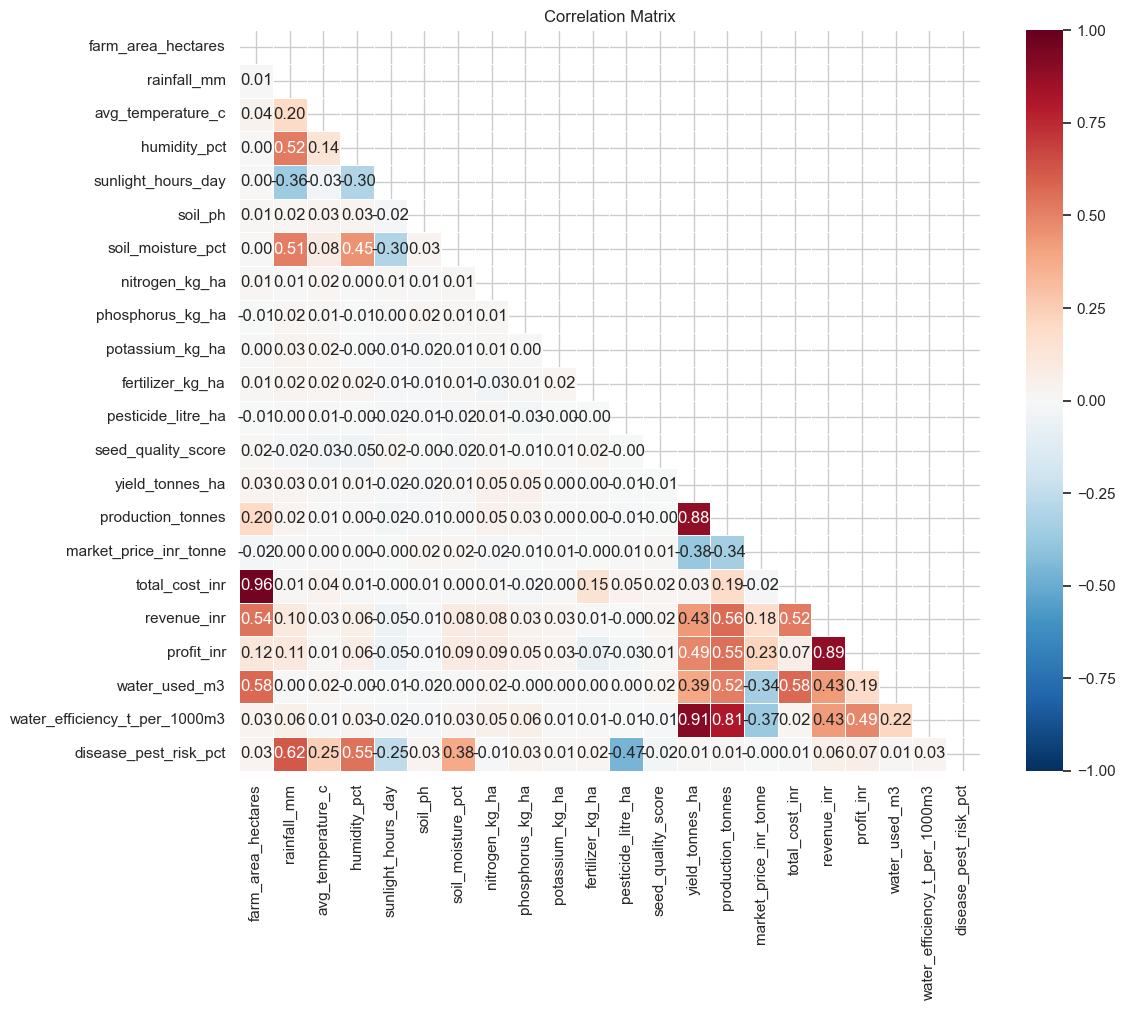

In [6]:
class BivariateAnalyzer:
    """Analyze relationships between pairs of variables."""
    
    def __init__(self, df: pd.DataFrame):
        self.df = df
        
    def plot_scatter(self, x_col: str, y_col: str, 
                     hue_col: Optional[str] = None,
                     figsize: Tuple[int, int] = (10, 6)):
        """Create scatter plot with optional hue."""
        fig, ax = plt.subplots(figsize=figsize)
        
        if hue_col and hue_col in self.df.columns:
            scatter = ax.scatter(
                self.df[x_col], self.df[y_col],
                c=pd.Categorical(self.df[hue_col]).codes,
                cmap='viridis', alpha=0.6, s=30
            )
            ax.legend(*scatter.legend_elements(), title=hue_col.replace('_', ' ').title())
        else:
            ax.scatter(self.df[x_col], self.df[y_col], 
                      alpha=0.6, s=30, color=plt.cm.viridis(0.6))
        
        ax.set_xlabel(x_col.replace('_', ' ').title())
        ax.set_ylabel(y_col.replace('_', ' ').title())
        ax.set_title(f'{y_col.replace("_", " ").title()} vs {x_col.replace("_", " ").title()}')
        
        # Add trend line
        z = np.polyfit(self.df[x_col], self.df[y_col], 1)
        p = np.poly1d(z)
        x_vals = np.linspace(self.df[x_col].min(), self.df[x_col].max(), 100)
        ax.plot(x_vals, p(x_vals), 'r--', alpha=0.5, label='Trend')
        ax.legend()
        
        plt.tight_layout()
        plt.show()
    
    def plot_box_by_category(self, numeric_col: str, cat_col: str,
                              figsize: Tuple[int, int] = (10, 6)):
        """Create boxplot of numeric variable by category."""
        if numeric_col not in self.df.columns or cat_col not in self.df.columns:
            print(f"❌ Columns '{numeric_col}' or '{cat_col}' not found")
            return
        
        fig, ax = plt.subplots(figsize=figsize)
        sns.boxplot(data=self.df, x=cat_col, y=numeric_col, 
                    palette='viridis', ax=ax)
        ax.set_title(f'{numeric_col.replace("_", " ").title()} by {cat_col.replace("_", " ").title()}')
        ax.set_xlabel(cat_col.replace('_', ' ').title())
        ax.set_ylabel(numeric_col.replace('_', ' ').title())
        plt.tight_layout()
        plt.show()
    
    def correlation_matrix(self, cols: Optional[List[str]] = None,
                           figsize: Tuple[int, int] = (12, 10)):
        """Display correlation matrix heatmap."""
        if cols is None:
            cols = self.df.select_dtypes(include=[np.number]).columns.tolist()
        
        cols = [c for c in cols if c in self.df.columns and self.df[c].nunique() > 1]
        
        corr = self.df[cols].corr()
        
        fig, ax = plt.subplots(figsize=figsize)
        mask = np.triu(np.ones_like(corr, dtype=bool))
        sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                    vmin=-1, vmax=1, center=0, square=True, linewidths=0.5, ax=ax)
        ax.set_title('Correlation Matrix')
        plt.tight_layout()
        plt.show()
        
        return corr

# Execute bivariate analysis
bivariate = BivariateAnalyzer(df)

# Scatter plots
bivariate.plot_scatter('rainfall_mm', 'yield_tonnes_ha')
bivariate.plot_scatter('farm_area_hectares', 'production_tonnes')

# Boxplots by category
bivariate.plot_box_by_category('yield_tonnes_ha', 'irrigation_method')

# Correlation matrix
corr = bivariate.correlation_matrix()

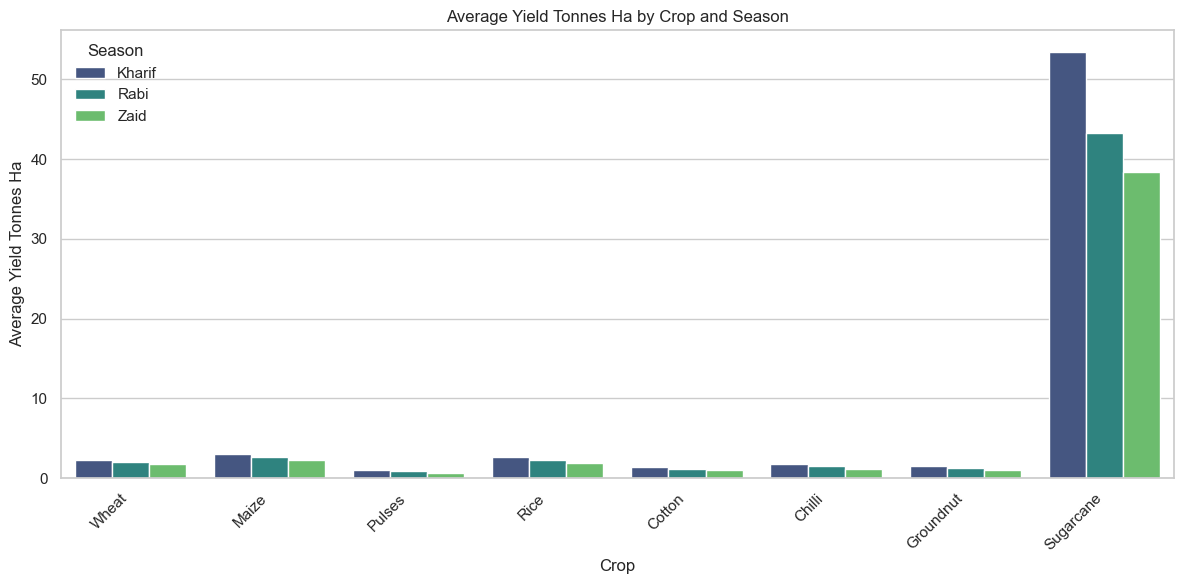

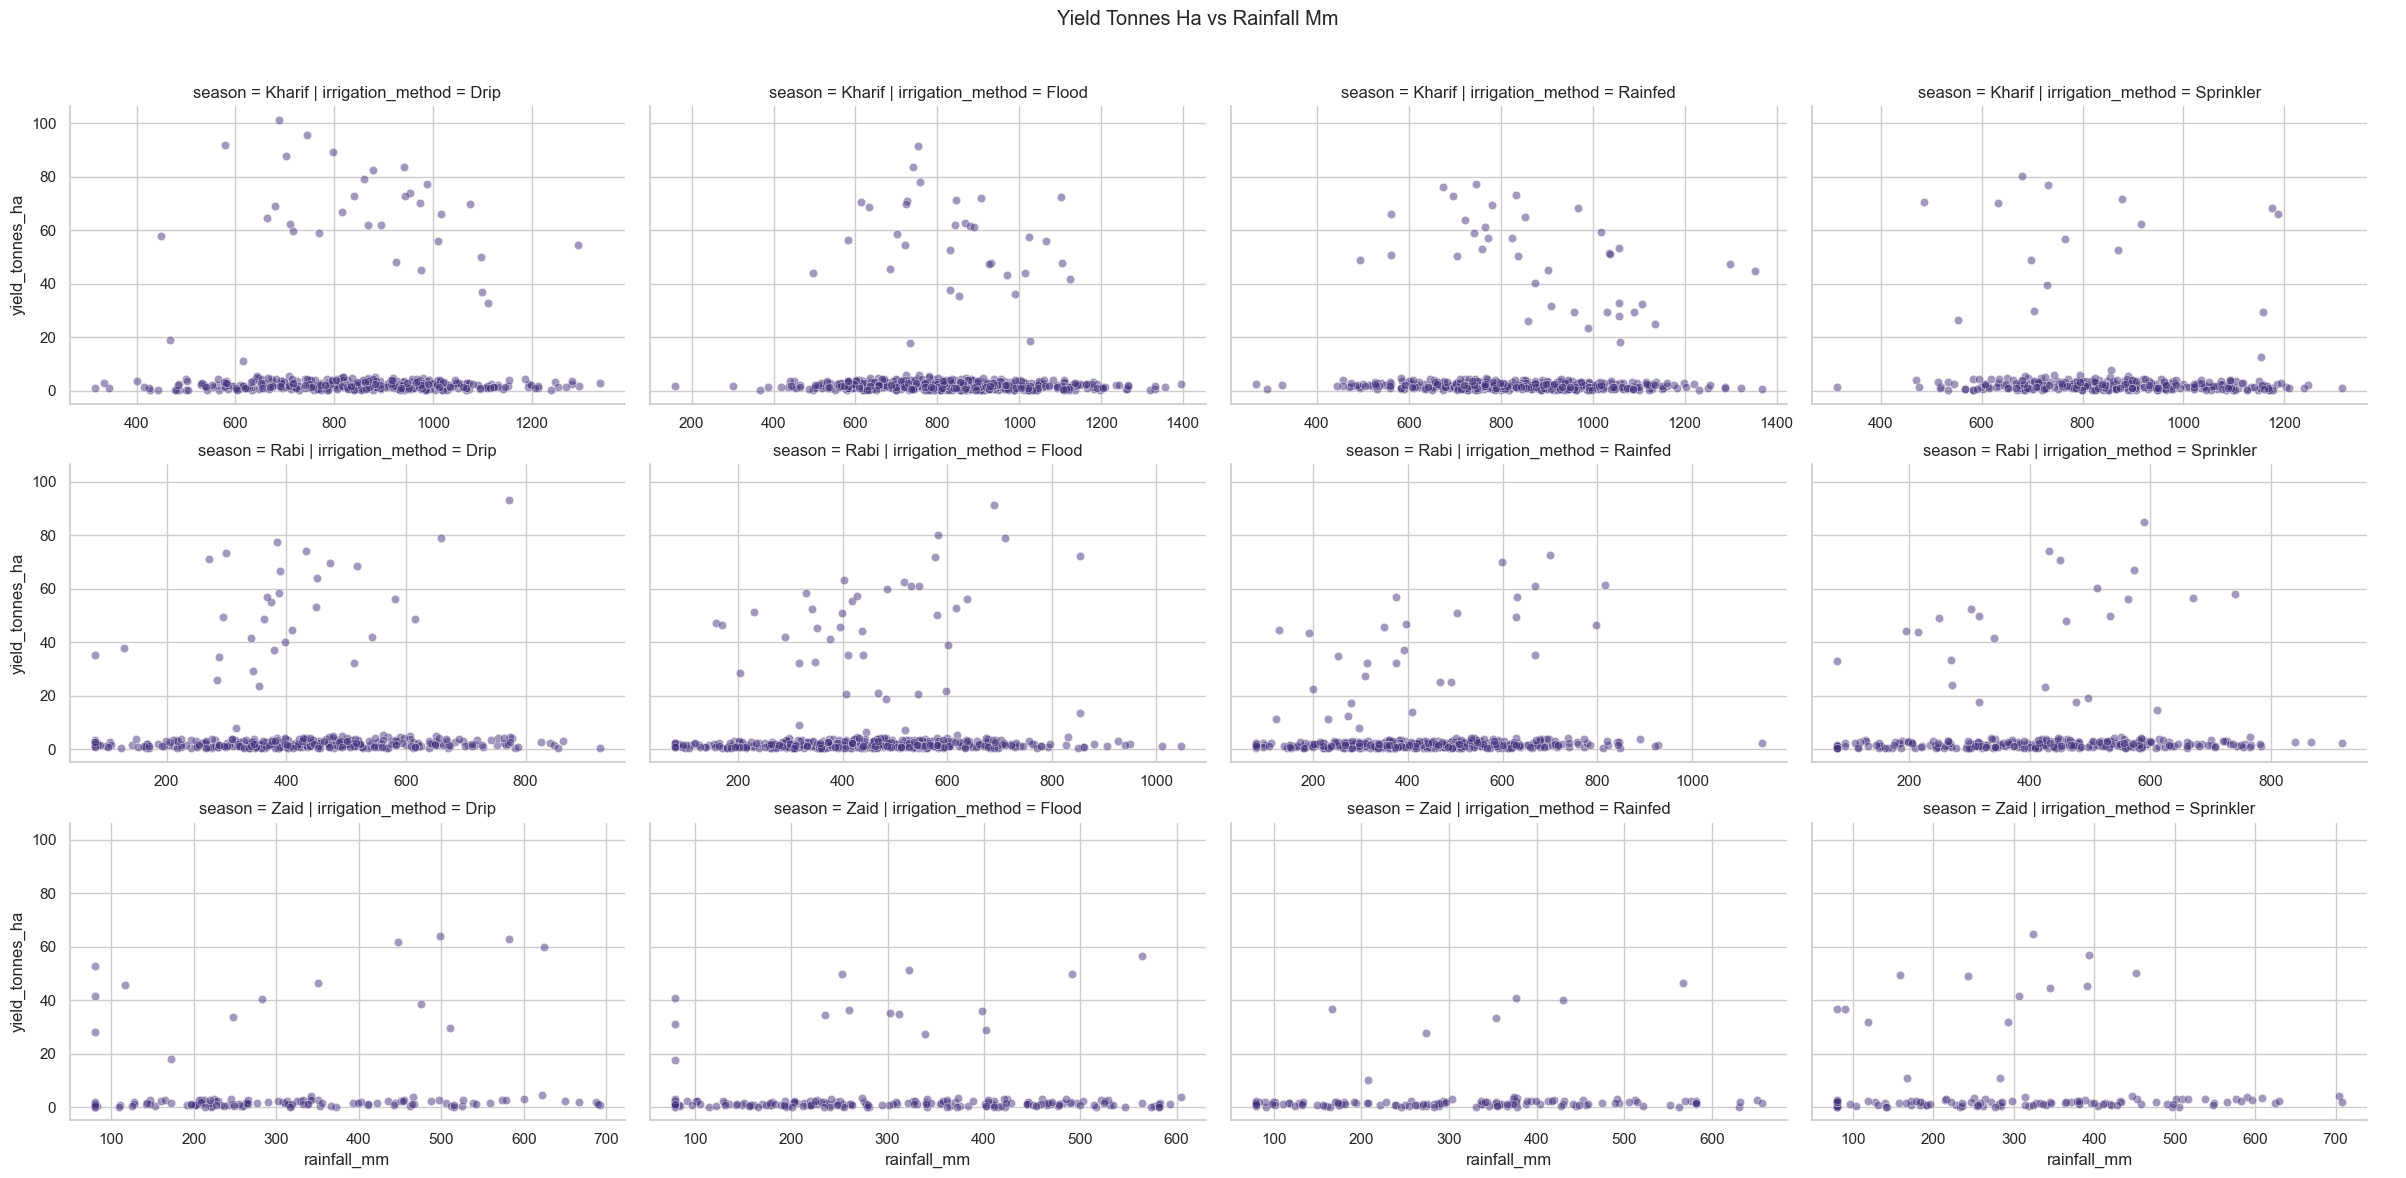

In [7]:
class MultivariateAnalyzer:
    """Analyze interactions between multiple variables."""
    
    def __init__(self, df: pd.DataFrame):
        self.df = df
        
    def plot_grouped_bars(self, x_col: str, y_col: str, hue_col: str,
                          figsize: Tuple[int, int] = (12, 6)):
        """Create grouped bar plot."""
        fig, ax = plt.subplots(figsize=figsize)
        
        sns.barplot(data=self.df, x=x_col, y=y_col, hue=hue_col,
                    palette='viridis', errorbar=None, ax=ax)
        
        ax.set_title(f'Average {y_col.replace("_", " ").title()} by {x_col.replace("_", " ").title()} and {hue_col.replace("_", " ").title()}')
        ax.set_xlabel(x_col.replace('_', ' ').title())
        ax.set_ylabel(f'Average {y_col.replace("_", " ").title()}')
        ax.legend(title=hue_col.replace('_', ' ').title())
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
    
    def plot_facet_grid(self, x_col: str, y_col: str, 
                         row_col: Optional[str] = None,
                         col_col: Optional[str] = None,
                         figsize: Tuple[int, int] = (14, 8)):
        """Create facet grid for multivariate exploration."""
        import seaborn as sns
        
        g = sns.FacetGrid(self.df, row=row_col, col=col_col, 
                         height=4, aspect=1.5, sharex=False)
        g.map(sns.scatterplot, x_col, y_col, alpha=0.5)
        g.add_legend()
        g.fig.subplots_adjust(top=0.9)
        g.fig.suptitle(f'{y_col.replace("_", " ").title()} vs {x_col.replace("_", " ").title()}')
        plt.show()

# Execute multivariate analysis
multivariate = MultivariateAnalyzer(df)

# Grouped bar plots
multivariate.plot_grouped_bars('crop', 'yield_tonnes_ha', 'season')

# Facet grid
multivariate.plot_facet_grid('rainfall_mm', 'yield_tonnes_ha', 
                             row_col='season', col_col='irrigation_method')


📊 Outlier Summary:
                       Column  Lower_Bound  Upper_Bound  Outlier_Count  Outlier_%
                   profit_inr  -696,111.00   763,567.00            404      10.10
            production_tonnes       -23.98        53.36            333       8.33
water_efficiency_t_per_1000m3        -3.57        10.38            322       8.05
              yield_tonnes_ha        -1.62         5.50            302       7.55
                water_used_m3    -6,072.75    16,171.25            276       6.90
                  revenue_inr  -736,519.00 1,780,911.00            240       6.00
              potassium_kg_ha        30.10       179.70             32       0.80
           sunlight_hours_day         4.35        10.35             26       0.65
             phosphorus_kg_ha        11.40       104.20             16       0.40
             fertilizer_kg_ha        19.14       352.04             15       0.38
               nitrogen_kg_ha        34.41       205.31             10       0

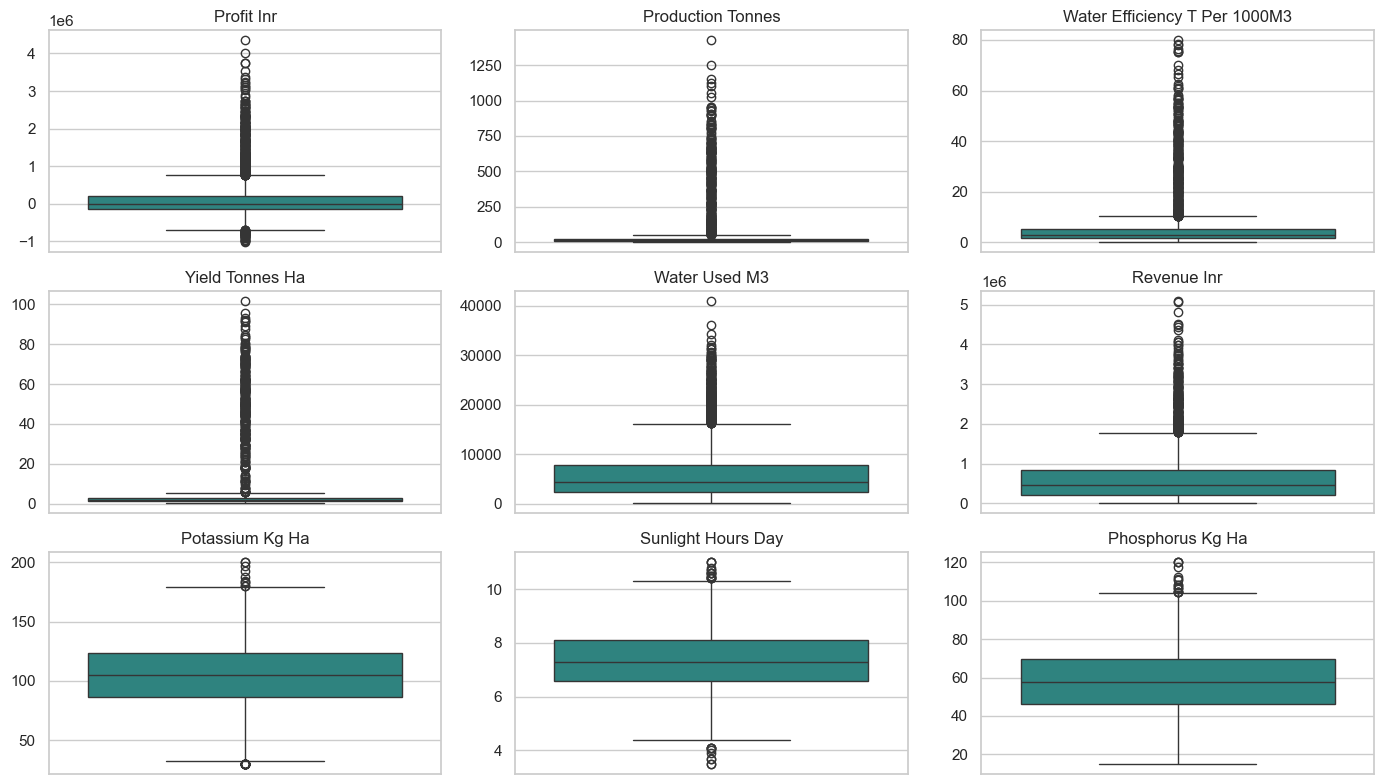

In [8]:
class OutlierAnalyzer:
    """Analyze outliers in the dataset."""
    
    def __init__(self, df: pd.DataFrame):
        self.df = df
        self.numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        
    def detect_outliers_iqr(self, col: str) -> Tuple[float, float, int, float]:
        """Detect outliers using IQR method."""
        q1 = self.df[col].quantile(0.25)
        q3 = self.df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        outliers = ((self.df[col] < lower_bound) | (self.df[col] > upper_bound)).sum()
        outlier_pct = (outliers / len(self.df)) * 100
        
        return lower_bound, upper_bound, outliers, outlier_pct
    
    def get_outlier_summary(self) -> pd.DataFrame:
        """Get outlier summary for all numerical columns."""
        summary = []
        for col in self.numeric_cols:
            if self.df[col].nunique() > 1:
                lb, ub, count, pct = self.detect_outliers_iqr(col)
                summary.append({
                    'Column': col,
                    'Lower_Bound': lb,
                    'Upper_Bound': ub,
                    'Outlier_Count': count,
                    'Outlier_%': round(pct, 2)
                })
        
        df_summary = pd.DataFrame(summary)
        return df_summary.sort_values('Outlier_Count', ascending=False)
    
    def plot_outlier_boxplots(self, cols: Optional[List[str]] = None,
                              figsize: Tuple[int, int] = (14, 8)):
        """Create boxplots for outlier visualization."""
        if cols is None:
            # Select columns with high outlier counts
            summary = self.get_outlier_summary()
            cols = summary.head(9)['Column'].tolist()
        
        cols = [c for c in cols if c in self.df.columns]
        n = len(cols)
        rows = (n + 1) // 3
        
        fig, axes = plt.subplots(rows, 3, figsize=figsize)
        axes = axes.flatten()
        
        for i, col in enumerate(cols):
            ax = axes[i]
            sns.boxplot(data=self.df, y=col, ax=ax, color=plt.cm.viridis(0.5))
            ax.set_title(col.replace('_', ' ').title())
            ax.set_ylabel('')
        
        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)
        
        plt.tight_layout()
        plt.show()

# Execute outlier analysis
outlier_analyzer = OutlierAnalyzer(df)
outlier_summary = outlier_analyzer.get_outlier_summary()
print("\n📊 Outlier Summary:")
print(outlier_summary.to_string(index=False))

outlier_analyzer.plot_outlier_boxplots()

In [9]:
class InsightsDashboard:
    """Generate key insights from the analysis."""
    
    def __init__(self, df: pd.DataFrame):
        self.df = df
        
    def generate(self) -> Dict[str, Any]:
        """Generate comprehensive insights."""
        insights = {}
        
        # Season performance
        season_yield = self.df.groupby('season')['yield_tonnes_ha'].mean()
        best_season = season_yield.idxmax()
        insights['best_season'] = best_season
        
        # Irrigation efficiency
        irr_yield = self.df.groupby('irrigation_method')['yield_tonnes_ha'].mean()
        best_irr = irr_yield.idxmax()
        insights['best_irrigation'] = best_irr
        
        # Top crops by season
        top_crops = {}
        for season in self.df['season'].unique():
            top = self.df[self.df['season'] == season].groupby('crop')['yield_tonnes_ha'].mean().idxmax()
            top_crops[season] = top
        insights['top_crops'] = top_crops
        
        # Profit analysis
        profitable = (self.df['profit_inr'] > 0).mean() * 100
        insights['profitable_%'] = round(profitable, 1)
        
        # Water efficiency
        best_water = self.df.loc[self.df['water_efficiency_t_per_1000m3'].idxmax()]['season']
        insights['best_water_efficiency'] = best_water
        
        return insights
    
    def display(self):
        """Display insights in a formatted manner."""
        insights = self.generate()
        
        print("\n" + "=" * 70)
        print("🔍 KEY INSIGHTS DASHBOARD")
        print("=" * 70)
        
        print(f"\n🌾 Best Season for Yield: {insights['best_season'].title()}")
        print(f"💧 Best Irrigation Method: {insights['best_irrigation']}")
        print(f"💰 Profitable Farms: {insights['profitable_%']:.1f}%")
        print(f"💧 Best Water Efficiency Season: {insights['best_water_efficiency'].title()}")
        
        print("\n🏆 Top Crops by Season:")
        for season, crop in insights['top_crops'].items():
            print(f"   • {season.title()}: {crop}")
        
        # Additional insights
        print("\n📈 Quick Statistics:")
        print(f"   • Average Yield: {self.df['yield_tonnes_ha'].mean():.2f} tonnes/ha")
        print(f"   • Average Profit: ₹{self.df['profit_inr'].mean():,.0f}")
        print(f"   • Average Rainfall: {self.df['rainfall_mm'].mean():.1f} mm")
        
        # Seasonal comparison
        print("\n📊 Seasonal Yield Averages:")
        season_yield = self.df.groupby('season')['yield_tonnes_ha'].mean().sort_values(ascending=False)
        for season, yield_val in season_yield.items():
            print(f"   • {season.title()}: {yield_val:.2f} tonnes/ha")

# Generate insights
dashboard = InsightsDashboard(df)
dashboard.display()


🔍 KEY INSIGHTS DASHBOARD

🌾 Best Season for Yield: Kharif
💧 Best Irrigation Method: Drip
💰 Profitable Farms: 50.8%
💧 Best Water Efficiency Season: Kharif

🏆 Top Crops by Season:
   • Kharif: Sugarcane
   • Rabi: Sugarcane
   • Zaid: Sugarcane

📈 Quick Statistics:
   • Average Yield: 5.24 tonnes/ha
   • Average Profit: ₹111,556
   • Average Rainfall: 600.9 mm

📊 Seasonal Yield Averages:
   • Kharif: 5.63 tonnes/ha
   • Rabi: 5.04 tonnes/ha
   • Zaid: 4.64 tonnes/ha


In [10]:
def generate_report(df: pd.DataFrame, insights: Dict[str, Any]) -> str:
    """Generate a comprehensive analysis report."""
    
    report = []
    report.append("=" * 80)
    report.append("SEASONAL AGRICULTURE PERFORMANCE ANALYSIS - FINAL REPORT")
    report.append("=" * 80)
    report.append("")
    
    # Dataset Overview
    report.append("📊 DATASET OVERVIEW")
    report.append("-" * 40)
    report.append(f"Total Records: {len(df):,}")
    report.append(f"Total Features: {len(df.columns)}")
    report.append("")
    
    # Key Findings
    report.append("🔍 KEY FINDINGS")
    report.append("-" * 40)
    
    # Best season
    best_season = df.groupby('season')['yield_tonnes_ha'].mean().idxmax()
    report.append(f"✅ Best Season: {best_season.title()}")
    
    # Irrigation
    best_irr = df.groupby('irrigation_method')['yield_tonnes_ha'].mean().idxmax()
    report.append(f"✅ Best Irrigation Method: {best_irr}")
    
    # Top crop
    top_crop = df.groupby('crop')['yield_tonnes_ha'].mean().idxmax()
    report.append(f"✅ Top Performing Crop: {top_crop}")
    
    # Profitability
    profitable = (df['profit_inr'] > 0).mean() * 100
    report.append(f"✅ Profitable Farms: {profitable:.1f}%")
    report.append("")
    
    # Recommendations
    report.append("💡 RECOMMENDATIONS")
    report.append("-" * 40)
    report.append("1. Prioritize crops suited to the best-performing season.")
    report.append("2. Adopt the most effective irrigation methods identified.")
    report.append("3. Focus on water efficiency improvements.")
    report.append("4. Consider region-specific crop recommendations.")
    report.append("")
    
    report.append("=" * 80)
    
    return "\n".join(report)

# Generate and print report
report = generate_report(df, dashboard.generate())
print(report)

# Save report to file
with open('agriculture_analysis_report.txt', 'w') as f:
    f.write(report)
print("\n✅ Report saved to 'agriculture_analysis_report.txt'")

SEASONAL AGRICULTURE PERFORMANCE ANALYSIS - FINAL REPORT

📊 DATASET OVERVIEW
----------------------------------------
Total Records: 4,000
Total Features: 28

🔍 KEY FINDINGS
----------------------------------------
✅ Best Season: Kharif
✅ Best Irrigation Method: Drip
✅ Top Performing Crop: Sugarcane
✅ Profitable Farms: 50.8%

💡 RECOMMENDATIONS
----------------------------------------
1. Prioritize crops suited to the best-performing season.
2. Adopt the most effective irrigation methods identified.
3. Focus on water efficiency improvements.
4. Consider region-specific crop recommendations.


✅ Report saved to 'agriculture_analysis_report.txt'
